In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
data = [
    ("cold and sneezing", "mild"),
    ("mild cough and sore throat", "mild"),
    ("low fever and tiredness", "mild"),
    ("slight body ache", "mild"),
    ("mild nausea after meal", "mild"),
    ("slight congestion, no breathing issue", "mild"),
    ("sore throat with light cough", "mild"),
    ("mild headache only", "mild"),
    ("severe chest pain and high fever", "severe"),
    ("shortness of breath", "severe"),
    ("vomiting and severe abdominal pain", "severe"),
    ("loss of consciousness", "severe"),
    ("fainting and rapid heartbeat", "severe"),
    ("high fever with dry cough", "severe"),
    ("severe dizziness and nausea", "severe"),
    ("trouble breathing and chest pain", "severe"),
    ("runny nose only", "mild"),
    ("sharp chest pain when inhaling", "severe"),
    ("minor muscle pain", "mild"),
    ("very high fever and fatigue", "severe"),
]

df = pd.DataFrame(data, columns=["text", "label"])

In [59]:
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.25, random_state=42, stratify=df["label"])

In [60]:
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [61]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [62]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

        mild       1.00      0.67      0.80         3
      severe       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



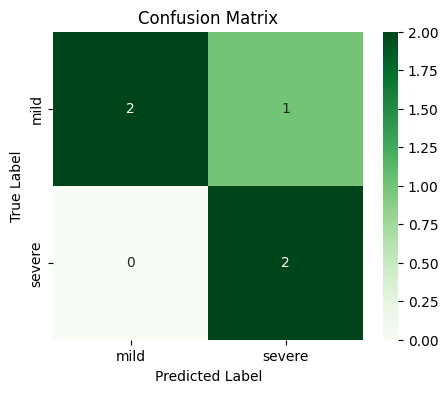

In [70]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [71]:
print("Enter your symptoms to predict severity.")
print("Type 'quit' or 'exit' to stop.")

while True:
    user_input = input("\nYour symptoms: ").strip()
    if user_input.lower() in ("quit", "exit"):
        print("Exiting")
        break
    if not user_input:
        print("Please enter your illness")
        continue

    vec = vectorizer.transform([user_input])
    pred = model.predict(vec)[0]
    conf = model.predict_proba(vec).max()

    print(f"Predicted Severity: {pred.upper()}  (Confidence: {conf:.2f})")

Enter your symptoms to predict severity.
Type 'quit' or 'exit' to stop.

Your symptoms: dry cold
Predicted Severity: SEVERE  (Confidence: 0.51)

Your symptoms: very high dry cough
Predicted Severity: SEVERE  (Confidence: 0.59)

Your symptoms:  severe chest pain and high fever
Predicted Severity: SEVERE  (Confidence: 0.68)

Your symptoms: quit
Exiting
